<a href="https://colab.research.google.com/github/PedroHNeves1505/CP2-SERS-Semestre-2/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CP2 | SERS | 2° Semestre**<br>
Integrante: Pedro Henrique Neves<br>
RM: 571382

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [6]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [8]:
# 1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique X (três entradas) e y (fonte).
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

dados = pd.read_csv('aneel_classificacao_orange.csv')

print('Tipos das colunas:')
print(dados.dtypes)

print('\nContagens por classe:')
print(dados['fonte'].value_counts())

print('\nValores ausentes:')
print(dados.isnull().sum())

print('\nDistribuições relevantes:')
print(dados.describe())

print('\nExplique x (três entradas) e y (fonte):')
print('X: Potência, latitude e longitude')
print('y: Fonte do empreendimento')

Tipos das colunas:
potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object

Contagens por classe:
fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64

Valores ausentes:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Distribuições relevantes:
        potencia_kw     latitude    longitude
count  3.876000e+03  3876.000000  3876.000000
mean   4.201468e+04   -12.693951   -46.158299
std    3.016366e+05     9.500523     8.357453
min    1.600000e-01   -33.722806   -69.941389
25%    4.400000e+02   -21.142110   -52.561817
50%    1.268000e+04   -10.469532   -47.393697
75%    3.000000e+04    -4.127788   -41.280013
max    1.123310e+07     3.831392     0.000000

Explique x (três entradas) e y (fonte):
X: Potência, latitude e longitude
y: Fonte do empreendimento


In [9]:
# 2. Faça uma divisão estratificada de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos somente com o treino.

X = dados[['potencia_kw', 'latitude', 'longitude']].values
y = dados['fonte'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
# 3. Escolha, justifique e treine três classificadores diferentes usando a mesma divisão. Eles não estão importados nem implementados neste notebook.

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

clf_lr = LogisticRegression(random_state=42)
clf_rf = RandomForestClassifier(random_state=42)
clf_knn = DecisionTreeClassifier()

clf_lr.fit(X_train, y_train)
clf_rf.fit(X_train, y_train)
clf_knn.fit(X_train, y_train)

print("\n\nMODELOS TREINADOS COM SUCESSO!")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(




MODELOS TREINADOS COM SUCESSO!


In [15]:
# 4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, macro) e apresente a matriz de confusão.

y_pred_lr = clf_lr.predict(X_test)
y_pred_rf = clf_rf.predict(X_test)
y_pred_knn = clf_knn.predict(X_test)

print("Accuracy:")
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("K-Nearest Neighbors:", accuracy_score(y_test, y_pred_knn))

print("\nPrecision:")
print("Logistic Regression:", precision_score(y_test, y_pred_lr, average='macro'))
print("Random Forest:", precision_score(y_test, y_pred_rf, average='macro'))
print("K-Nearest Neighbors:", precision_score(y_test, y_pred_knn, average='macro'))

print("\nRecall:")
print("Logistic Regression:", recall_score(y_test, y_pred_lr, average='macro'))
print("Random Forest:", recall_score(y_test, y_pred_rf, average='macro'))
print("K-Nearest Neighbors:", recall_score(y_test, y_pred_knn, average='macro'))

print("\nF1 Score:")
print("Logistic Regression:", f1_score(y_test, y_pred_lr, average='macro'))
print("Random Forest:", f1_score(y_test, y_pred_rf, average='macro'))
print("K-Nearest Neighbors:", f1_score(y_test, y_pred_knn, average='macro'))

print("\nMatriz de Confusão:")
print("Logistic Regression:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nRandom Forest:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nK-Nearest Neighbors:")
print(confusion_matrix(y_test, y_pred_knn))

Accuracy:
Logistic Regression: 0.7126288659793815
Random Forest: 0.9755154639175257
K-Nearest Neighbors: 0.9626288659793815

Precision:
Logistic Regression: 0.7064357857893094
Random Forest: 0.9768806647225744
K-Nearest Neighbors: 0.9628390680813751

Recall:
Logistic Regression: 0.7063063063063063
Random Forest: 0.9741366366366367
K-Nearest Neighbors: 0.9618243243243243

F1 Score:
Logistic Regression: 0.7058356847913609
Random Forest: 0.9752515228975418
K-Nearest Neighbors: 0.962303227862174

Matriz de Confusão:
Logistic Regression:
[[147  42  51]
 [ 31 235  30]
 [ 43  26 171]]

Random Forest:
[[235   4   1]
 [  2 294   0]
 [  5   7 228]]

K-Nearest Neighbors:
[[232   4   4]
 [  2 288   6]
 [  5   8 227]]


5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use SigTipoGeracao, nomes, CEG ou descrições da fonte como entradas.<br>

******

**1. Qual modelo escolheria?**
O modelo escolhido seria o Random Forest.

* Justificativa: Ele obteve o melhor desempenho disparado em todas as métricas principais: Acurácia 97,55%, Precisão 97,69%, Recall 97,41% e F1-Score 97,53%. Superou tanto a Regressão Logística (que ficou em torno de 70% em todas as métricas) quanto o KNN (cerca de 96%). Ele lida muito bem com relações não-lineares complexas nos dados sem sofrer tanto com o overfitting quanto outros algoritmos isolados, graças à média de várias árvores de decisão.

**2. Quais classes ele mais confunde?**
* O modelo cometeu poucos erros, mas a maior confusão ocorreu entre a Classe 2 e a Classe 1, onde 7 amostras da Classe 2 foram incorretamente previstas como Classe 1

**3. Por que potência e localização podem não bastar para uma aplicação real?**

* Sobreposição Geográfica e de Porte: Diferentes tipos de fontes geradoras de energia podem operar na mesma faixa de potência e estar instaladas exatamente na mesma região ou município, tornando impossível diferenciá-las apenas por esses dois eixos.

* Falta de Dados Operacionais e Temporais: A geração de energia varia dinamicamente de acordo com sazonalidade, clima (incidência solar, ventos, vazão) e horário. Duas usinas com potências idênticas na mesma cidade podem ter perfis de operação completamente diferentes dependendo da tecnologia.

* Ausência de Contexto Técnico: Ignorar características construtivas e operacionais da usina impede que o modelo compreenda padrões físicos fundamentais, tornando-o frágil a mudanças estruturais na rede elétrica ou à inclusão de novas tecnologias.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [16]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [17]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [18]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [19]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

In [20]:
# 1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina X (cinco entradas) e y (radiacao_w_m2).

dados = pd.read_csv('meteo_regressao_orange.csv')

print('Colunas do CSV:')
print(dados.columns)

print('\nValores ausentes:')
print(dados.isnull().sum())

print('\nVisualização:')
print(dados.head())

print('\nExplique x (cinco entradas) e y (radiacao_w_m2):')
print('X: Temperatura, umidade, nuvens, vento e hora')
print('y: Radiação solar')

Colunas do CSV:
Index(['data_hora', 'temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh',
       'hora', 'radiacao_w_m2'],
      dtype='object')

Valores ausentes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64

Visualização:
          data_hora  temperatura_c  umidade_pct  nuvens_pct  vento_kmh  hora  \
0  2025-04-01T07:00           25.3           74         100       17.7     7   
1  2025-04-01T08:00           26.5           66         100       18.1     8   
2  2025-04-01T09:00           28.4           55          97       18.0     9   
3  2025-04-01T10:00           30.8           44          21       18.4    10   
4  2025-04-01T11:00           32.7           36          26       20.1    11   

   radiacao_w_m2  
0          116.0  
1          269.0  
2          529.0  
3          797.0  
4          880.0  

Explique x (cinco entradas) e y (radiacao_w_m2):
X: Temperatura, umidade, 

In [25]:
# 2. Mantenha as linhas em ordem de data_hora: use aproximadamente 80% das primeiras horas para treino e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.

X = dados[['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']].values
y = dados['radiacao_w_m2'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Modelos de regressão treinados com sucesso!")

Modelos de regressão treinados com sucesso!


In [28]:
# 3. Escolha, justifique e treine três algoritmos de regressão diferentes com a mesma divisão. Os imports e a implementação são sua responsabilidade.

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

reg_linear = LinearRegression()
reg_rf = RandomForestRegressor(random_state=42)
reg_knn = KNeighborsRegressor()

reg_linear.fit(X_train, y_train)
reg_rf.fit(X_train, y_train)
reg_knn.fit(X_train, y_train)

y_pred_lr = reg_linear.predict(X_test)
y_pred_rf = reg_rf.predict(X_test)
y_pred_knn = reg_knn.predict(X_test)

print("--- R² Score (Coeficiente de Determinação) ---")
print("Linear Regression:", r2_score(y_test, y_pred_lr))
print("Random Forest:", r2_score(y_test, y_pred_rf))
print("K-Nearest Neighbors:", r2_score(y_test, y_pred_knn))

print("\n--- MSE (Erro Quadrático Médio) ---")
print("Linear Regression:", mean_squared_error(y_test, y_pred_lr))
print("Random Forest:", mean_squared_error(y_test, y_pred_rf))
print("K-Nearest Neighbors:", mean_squared_error(y_test, y_pred_knn))

print("\n--- MAE (Erro Absoluto Médio) ---")
print("Linear Regression:", mean_absolute_error(y_test, y_pred_lr))
print("Random Forest:", mean_absolute_error(y_test, y_pred_rf))
print("K-Nearest Neighbors:", mean_absolute_error(y_test, y_pred_knn))

--- R² Score (Coeficiente de Determinação) ---
Linear Regression: 0.6210519251653912
Random Forest: 0.9264446393883998
K-Nearest Neighbors: 0.5726674291233012

--- MSE (Erro Quadrático Médio) ---
Linear Regression: 24816.37471797668
Random Forest: 4816.95913681592
K-Nearest Neighbors: 27984.9560199005

--- MAE (Erro Absoluto Médio) ---
Linear Regression: 121.59184811373183
Random Forest: 48.328407960198994
K-Nearest Neighbors: 126.4995024875622


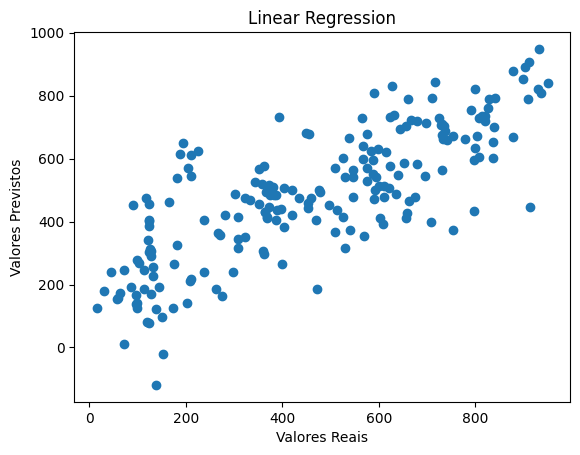

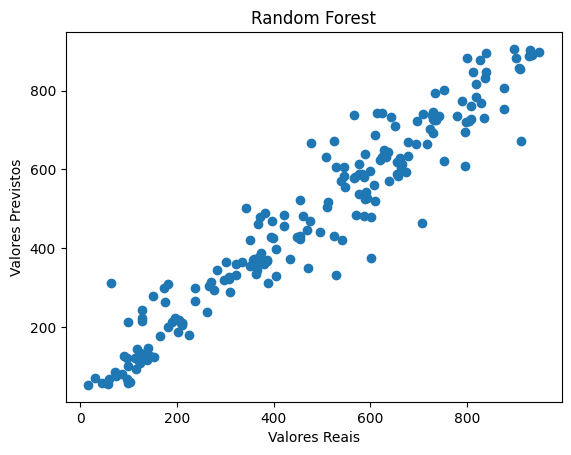

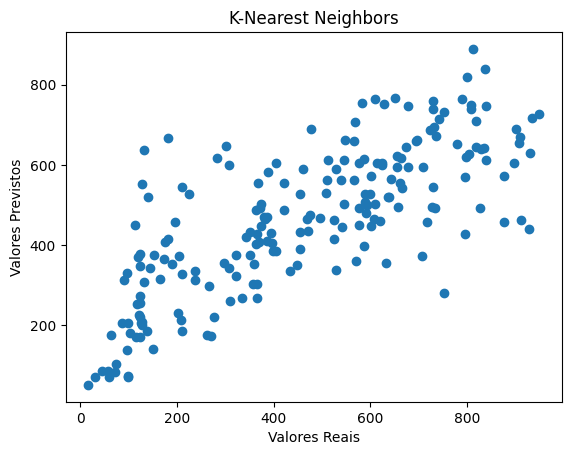

In [30]:
# 4. Compare MAE (W/m²), MSE ((W/m²)²) e R²; faça um gráfico de valores reais × previstos de pelo menos um modelo.

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Linear Regression')
plt.show()

plt.scatter(y_test, y_pred_rf)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Random Forest')
plt.show()

plt.scatter(y_test, y_pred_knn)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('K-Nearest Neighbors')
plt.show()

5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação não prevê automaticamente a energia produzida por um sistema fotovoltaico.

******

**1. Interpretação dos Erros**
* Regressão Linear: Apresenta uma dispersão maior dos pontos em relação à linha ideal de 45 graus, com previsões chegando a gerar valores negativos absurdos (abaixo de zero) e uma dispersão ampla verticalmente, indicando maior erro e dificuldade em capturar relações não-lineares.

* Random Forest: É o modelo que apresenta o melhor desempenho visual. Os pontos estão muito mais concentrados ao longo de uma linha diagonal imaginária perfeita (valores reais próximos aos previstos), demonstrando menor erro residual e alta capacidade de generalização.

* K-Nearest Neighbors (KNN): Mostra um comportamento intermediário, mas com uma dispersão visível (especialmente em valores mais altos), onde o modelo começa a "estagnar" ou espalhar as previsões de forma mais ruidosa.

**2. O Peso da Hora**
* A radiação varia drasticamente ao longo do dia devido à posição relativa do Sol (zero à noite, pico ao meio-dia solar).

* Sem a inclusão da hora ou do momento do dia como variável preditiva, o modelo perde a referência cronológica fundamental, tratando instantes de baixa luminosidade matinal ou vespertina da mesma forma que o meio-dia, o que infla severamente os erros de predição.

**3. Por que a estimativa da radiação não prevê automaticamente a energia produzida?**
Estimar a radiação solar incidente (quanto sol atinge o local) não é suficiente para determinar de forma direta e automática a energia elétrica gerada por um sistema fotovoltaico pelas seguintes razões:

* Eficiência dos Painéis: Os módulos fotovoltaicos possuem uma taxa de conversão limitada (eficiência nominal), transformando apenas uma fração da radiação recebida em eletricidade.

* Perdas de Sistema (PR - Performance Ratio): Fatores reais reduzem a geração, como perdas em inversores, queda de eficiência por aquecimento das placas (coeficiente de temperatura), sujeira acumulada, sombreamento e perdas nos cabos.

* Especificações Geométricas e de Instalação: A energia gerada depende diretamente da inclinação e da orientação (azimute) dos painéis solares, parâmetros físicos que variam em cada projeto e que não são capturados puramente pelo volume de radiação bruta no ambiente.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)